# Primer acercamiento a Pennylane

In [83]:
import pennylane as qml
from pennylane import numpy as np

In [84]:
dev = qml.device('default.qubit', wires = 2)

In [85]:
@qml.qnode(dev)
def circuit(theta):
    qml.PauliX(wires = 1)
    qml.CNOT(wires = [1,0])
    qml.RY(theta, wires = 0)

    return qml.expval(qml.PauliZ(wires=0))

In [86]:
print(circuit(np.pi))

1.0


In [87]:
import matplotlib.pyplot as plt

In [88]:
thetas = np.arange(-np.pi, np.pi, 0.1)
measurements = np.zeros(len(thetas)) # crea un tensor de ceros del mismo tamaño que thetas

In [89]:
for i, theta in enumerate(thetas):
    measurements[i] = circuit(theta)

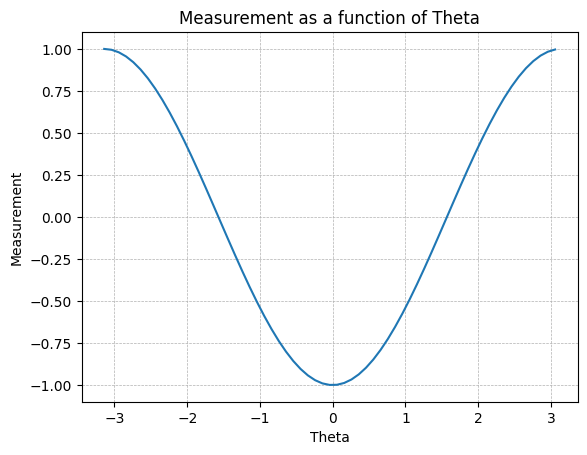

In [90]:
plt.plot(thetas, measurements)
plt.xlabel('Theta')
plt.ylabel('Measurement')
plt.title('Measurement as a function of Theta')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

## Devices

### Lightning devices
Los dispositivos de tipo "lightning" en Pennylane son simuladores de circuitos cuánticos que utilizan técnicas de optimización para acelerar la simulación. Estos dispositivos están diseñados para ser eficientes y rápidos, lo que los hace ideales para simular circuitos cuánticos más grandes y complejos. Utilizan algoritmos de optimización para reducir el tiempo de simulación, lo que permite a los usuarios experimentar con circuitos cuánticos sin tener que esperar largos tiempos de ejecución. Está escrito en C++ y se integra con Python a través de una interfaz, lo que lo hace accesible para los usuarios de Pennylane.

In [91]:
# ligtning.qubit device is writen in C++ and is optimized for performance, 
# making it faster than the default.qubit device for certain operations. 
# It is particularly efficient for simulating larger quantum circuits and can 
# take advantage of multi-threading capabilities of modern CPUs.
dev_2 = qml.device('lightning.qubit', wires = 1)

@qml.qnode(dev_2)
def circuit_2(theta):
    qml.Hadamard(wires=0)
    qml.RZ(theta, wires=0)
    qml.Hadamard(wires=0)
    return qml.probs(wires=0)

circuit_2(np.pi/2)

array([0.5, 0.5])

### default.mixed
El dispositivo "default.mixed" en Pennylane es un simulador de circuitos cuánticos que permite la simulación de estados mixtos. A diferencia de los dispositivos que solo simulan estados puros, "default.mixed" puede manejar estados que son combinaciones probabilísticas de estados puros, lo que es esencial para simular sistemas cuánticos en presencia de ruido o decoherencia. Este dispositivo es útil para estudiar la dinámica de sistemas cuánticos abiertos y para realizar simulaciones más realistas de experimentos cuánticos.

In [92]:
# default.mixed
dev_3 = qml.device('default.mixed', wires = 4)

@qml.qnode(dev_3)
def circuit_3():
    for i in range(4):
        qml.Hadamard(wires=i)
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[1,2])
    qml.CNOT(wires=[2,3])
    return qml.expval(qml.PauliZ(wires=3))

print(circuit_3())

0.0


### Default gaussian
El dispositivo "default.gaussian" en Pennylane es un simulador de circuitos cuánticos que se especializa en la simulación de sistemas cuánticos continuos, como los modos ópticos. Este dispositivo utiliza técnicas de simulación basadas en la representación gaussiana de los estados cuánticos, lo que permite simular sistemas con un gran número de modos y partículas. Es especialmente útil para estudiar fenómenos como la interferencia cuántica y la generación de estados entrelazados en sistemas ópticos.

### Optimizacion

Primero veamos que sucede con el dispositivo "lightning.qubit" al variar un parametro de una puerta de rotación

In [93]:
dev_4 = qml.device('lightning.qubit', wires =1)

@qml.qnode(dev_4)
def circuit_4(theta):
    qml.PauliX(wires=0)
    qml.RY(theta, wires=0)
    return qml.expval(qml.PauliZ(wires=0))
circuit_4(0.1)

-0.9950041652780258

In [94]:
thetas_2 = np.linspace(-np.pi, np.pi, 100)
measurements_2 = []
for theta in thetas_2:
    measurements_2.append(circuit_4(theta))

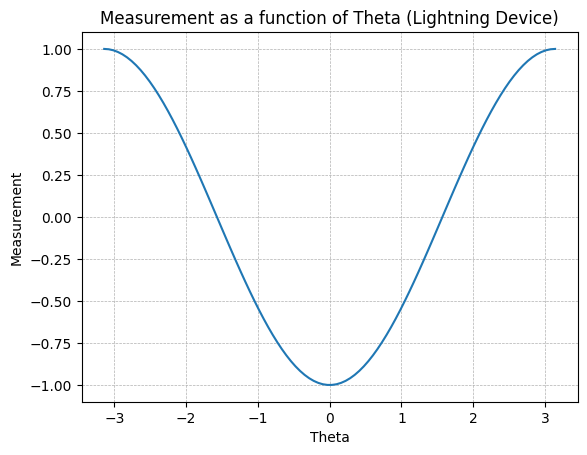

In [95]:
fig ,ax = plt.subplots()
ax.plot(thetas_2, measurements_2)
ax.set_xlabel('Theta')
ax.set_ylabel('Measurement')
ax.set_title('Measurement as a function of Theta (Lightning Device)')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

Para optimizar el circuito partiremos de un valor específico de theta, y luego, con pequeños pasos, avanzaremos en sentido contrario de donde se encuentra apuntando el gradiente de la función de costo, para así encontrar un mínimo local.

In [96]:
theta_4 = np.array([-2.], requires_grad=True)
opt = qml.GradientDescentOptimizer(stepsize=0.1)

\begin{equation}
\theta_{n+1} = \theta_n - \alpha \nabla C(\theta_n)
\end{equation}
donde 
$\alpha$ es la tasa de aprendizaje, y $\nabla C(\theta_n)$ es el gradiente de la función de costo con respecto a $\theta_n$, para este caso es el circuito cuántico. Este proceso se repite iterativamente hasta que se alcance un mínimo local o se cumpla un criterio de convergencia.

In [97]:
n_it = 100
for it in range(n_it):
    theta_4, prev_cost = opt.step_and_cost(circuit_4, theta_4)
    if it % 10 == 0:
        print("Theta:", theta_4, "Cost:", circuit_4(theta_4))

Theta: [-1.9090702573] Cost: [0.3318593361]
Theta: [-0.9526825103] Cost: [-0.5794990038]
Theta: [-0.3599983216] Cost: [-0.935897415]
Theta: [-0.1269310502] Cost: [-0.9919550643]
Theta: [-0.0443192495] Cost: [-0.9990180628]
Theta: [-0.0154557659] Cost: [-0.999880562]
Theta: [-0.0053892026] Cost: [-0.9999854783]
Theta: [-0.0018791034] Cost: [-0.9999982345]
Theta: [-0.000655203] Cost: [-0.9999997854]
Theta: [-0.0002284552] Cost: [-0.9999999739]


## Differentiation methods

In [98]:
np.set_printoptions(precision=10)

In [99]:
dev_5 = qml.device("default.qubit", wires = 2)
@qml.qnode(dev_5)
def circuit_5(params):
    qml.RY(params[0], wires=0)
    qml.RX(params[1], wires=1)
    return qml.expval(qml.PauliZ(wires=0) + qml.PauliZ(wires=1))

In [100]:
params = np.array([np.pi/4, np.pi/4])
print(circuit_5(params))

1.414213562373095


Ahora veamos como se pueden diferenciar los circuitos cuánticos utilizando Pennylane. Para esto, utilizaremos el dispositivo "default.qubit" y un circuito con dos parámetros de rotación. Luego, calcularemos el valor del circuito para un conjunto específico de parámetros y veremos cómo se pueden obtener los gradientes con respecto a esos parámetros.

Para ello recordamos que una diferenciación numérica se puede realizar utilizando la fórmula de diferencia finita:
\begin{equation}
\frac{\partial C}{\partial \theta} \approx \frac{C(\theta + h) - C(\theta - h)}{2h}
\end{equation}

donde $C$ es la función de costo, $\theta$ es el parámetro con respecto al cual se está diferenciando, y $h$ es un pequeño valor que representa el paso de diferencia finita. Esta fórmula proporciona una aproximación del gradiente de la función de costo con respecto a $\theta$ utilizando los valores de la función en puntos cercanos a $\theta$. Es importante elegir un valor adecuado para $h$ para obtener una buena aproximación del gradiente.

Esta fórmula proviene de la relación entre la derivada de una función y su aproximación mediante diferencias finitas, que es una técnica común en análisis numérico para estimar la derivada de una función a partir de sus valores en puntos cercanos.
\begin{equation}
\frac{\partial C}{\partial \theta} = \lim_{h \to 0} \frac{C(\theta + h) - C(\theta - h)}{2h}
\end{equation}

In [101]:
def my_finite_diff_grad(params, h=1e-7):
    gradient = np.zeros_like(params) # np.zeros crea un tensor de ceros del mismo tamaño que params

    for i in range(len(params)):
        # primer termino del numerador de la formula de la derivada
        params[i] += h
        gradient[i] += circuit_5(params)

        # segundo termino del numerador de la formula de la derivada
        params[i] -= 2*h
        gradient[i] -= circuit_5(params)

        # división por 2h para obtener la derivada
        gradient[i] /= (2*h)

        # restaurar el valor original del parametro
        params[i] += h

    return gradient

Ahora para comparar los resultados de una diferenciación escrita vs alguna preestablecida en Pennylane podemos usar diff_method = "finite-diff" para la diferenciación numérica, o diff_method = "parameter-shift" para la diferenciación analítica. La diferenciación analítica es generalmente más precisa y eficiente que la diferenciación numérica, especialmente para circuitos cuánticos con muchos parámetros, ya que evita los errores de aproximación asociados con la diferencia finita. Sin embargo, la fórmula que nosotros usaremos aquí para comparar es la diferencia finita, ya que es más fácil de implementar y entender en el contexto de la optimización de circuitos cuánticos.

In [102]:
# Diferenciación preestablecida en Pennylane
@qml.qnode(dev_5, diff_method="finite-diff")
# mismo circuito que circuit_5 pero con diferenciación preestablecida
def circuit_6(params):
    qml.RY(params[0], wires=0)
    qml.RX(params[1], wires=1)
    return qml.expval(qml.PauliZ(wires=0) + qml.PauliZ(wires=1))

In [103]:
params = np.array([np.pi/4, np.pi/3], requires_grad=True) # requires_grad=True es necesario para que Pennylane pueda calcular el gradiente de los parámetros
print(my_finite_diff_grad(params))
print((qml.grad(circuit_6)(params))) # usamos qml.grad para calcular el gradiente de circuit_6 con respecto a params

[-0.7071067798 -0.8660254025]
[-0.7071068131 -0.8660254314]


Podemos ver que en el primer elemento tenemos 6 cifras de similitud mientras que en el segundo elemento tenemos 7 cifras.

#### Parameter-shift rule
La regla de desplazamiento de parámetros (parameter-shift rule) es una técnica utilizada en la optimización de circuitos cuánticos para calcular el gradiente de una función de costo con respecto a los parámetros del circuito. Esta regla se basa en la idea de que el gradiente de una función de costo con respecto a un parámetro específico puede ser calculado evaluando la función de costo en dos puntos desplazados alrededor del valor actual del parámetro. La fórmula para la regla de desplazamiento de parámetros es la siguiente:
\begin{equation}
\frac{\partial C}{\partial \theta} = \frac{C(\theta + s) - C(\theta - s)}{2 \sin(s)}
\end{equation}
donde $C$ es la función de costo, $\theta$ es el parámetro con respecto al cual se está diferenciando, y $s$ es un pequeño valor que representa el desplazamiento de parámetros. Esta fórmula proporciona una forma eficiente de calcular el gradiente de la función de costo con respecto a los parámetros del circuito cuántico, lo que es esencial para la optimización de circuitos cuánticos utilizando técnicas como el descenso de gradiente. Una ventaja es que no necesitamos elegir un valor adecuado para $s$ como en la diferencia finita, ya que la fórmula de desplazamiento de parámetros es exacta para cualquier valor de $s$ que no sea un múltiplo de $\pi$. Contrario al pequeño valor de h que se necesita para la diferencia finita, lo que puede introducir errores de aproximación si no se elige correctamente.

In [109]:
def my_parameter_shift_grad(params, s=np.pi/3):
    gradient = np.zeros_like(params)

    for i in range(len(params)):
        # primer termino del numerador de la formula de la regla de desplazamiento de parámetros
        params[i] += s
        gradient[i] += circuit_5(params)

        # segundo termino del numerador de la formula de la regla de desplazamiento de parámetros
        params[i] -= 2*s
        gradient[i] -= circuit_5(params)

        # división por 2*sin(s) para obtener la derivada
        gradient[i] /= (2*np.sin(s))

        # restaurar el valor original del parametro
        params[i] += s

    return gradient

In [107]:
@qml.qnode(dev_5, diff_method="parameter-shift")
def circuit_7(params):
    qml.RY(params[0], wires=0)
    qml.RX(params[1], wires=1)
    return qml.expval(qml.PauliZ(wires=0) + qml.PauliZ(wires=1))

In [110]:
print(qml.grad(circuit_7)(params))
print(my_parameter_shift_grad(params))

[-0.7071067812 -0.8660254038]
[-0.7071067812 -0.8660254038]
